# Data Wrangling II - Assignment 2

### Import required libraries

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

### Loading dataset

In [2]:
df = pd.read_csv("StudentsPerformance_modified.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72.0,74.0
1,female,group C,some college,standard,completed,69,90.0,88.0
2,female,group B,master's degree,standard,none,90,95.0,93.0
3,male,group A,associate's degree,free/reduced,none,47,57.0,44.0
4,male,group C,some college,standard,none,76,78.0,75.0


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   str    
 1   race/ethnicity               1000 non-null   str    
 2   parental level of education  1000 non-null   str    
 3   lunch                        1000 non-null   str    
 4   test preparation course      1000 non-null   str    
 5   math score                   992 non-null    str    
 6   reading score                994 non-null    float64
 7   writing score                991 non-null    float64
dtypes: float64(2), str(6)
memory usage: 62.6 KB


### Create dataset
Modifying existing dataset by adding attendance, hours studied, sports and final grade:

In [8]:
df['attendance'] = np.random.randint(60,100, size = len(df))
df['study_hours'] = np.random.randint(1,8, size = len(df))
df['sports'] = np.random.choice(['yes','no'], size = len(df))

Introducing some inconsistencies in added data:

In [10]:
df.loc[10, 'attendance'] = np.nan
df.loc[8, 'attendance'] = 150
df.loc[12, 'study_hours'] = np.nan
df.loc[22, 'sports'] = np.nan

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   str    
 1   race/ethnicity               1000 non-null   str    
 2   parental level of education  1000 non-null   str    
 3   lunch                        1000 non-null   str    
 4   test preparation course      1000 non-null   str    
 5   math score                   992 non-null    str    
 6   reading score                994 non-null    float64
 7   writing score                991 non-null    float64
 8   attendance                   999 non-null    float64
 9   study_hours                  999 non-null    float64
 10  sports                       999 non-null    str    
dtypes: float64(4), str(7)
memory usage: 86.1 KB


### Data Cleaning

In [13]:
df.dtypes

gender                             str
race/ethnicity                     str
parental level of education        str
lunch                              str
test preparation course            str
math score                         str
reading score                  float64
writing score                  float64
attendance                     float64
study_hours                    float64
sports                             str
dtype: object

In [14]:
df['math score'] = pd.to_numeric(df['math score'], errors = 'coerce')

In [17]:
df.dtypes

gender                             str
race/ethnicity                     str
parental level of education        str
lunch                              str
test preparation course            str
math score                     float64
reading score                  float64
writing score                  float64
attendance                     float64
study_hours                    float64
sports                             str
dtype: object

Performed type conversion of math score from string to float.

In [20]:
df.isnull().sum()

gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
math score                     43
reading score                   6
writing score                   9
attendance                      1
study_hours                     1
sports                          1
dtype: int64

In [21]:
df['writing score'] = df['writing score'].fillna(df['writing score'].mean())

In [22]:
df['reading score'] = df['reading score'].fillna(df['reading score'].mean())

In [23]:
df['math score'] = df['math score'].fillna(df['math score'].mean())

In [25]:
df = df.dropna(subset = ['attendance', 'study_hours', 'sports'])

In [26]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
attendance                     0
study_hours                    0
sports                         0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,attendance,study_hours,sports
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0,71.0,1.0,no
1,female,group C,some college,standard,completed,69.0,90.0,88.0,89.0,6.0,yes
2,female,group B,master's degree,standard,none,90.0,95.0,93.0,84.0,5.0,no
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,44.0,99.0,6.0,no
4,male,group C,some college,standard,none,76.0,78.0,75.0,83.0,7.0,no


Handled missing values by imputing math, reading and writing score with means and dropping the NaN values from attendance, study hours and sports (only 1 in each, can afford to drop).

In [37]:
numeric_cols = ['math score', 'reading score', 'writing score', 'attendance', 'study_hours']

### Handling outliers

##### Boxplot method (allows us to visualize outliers):

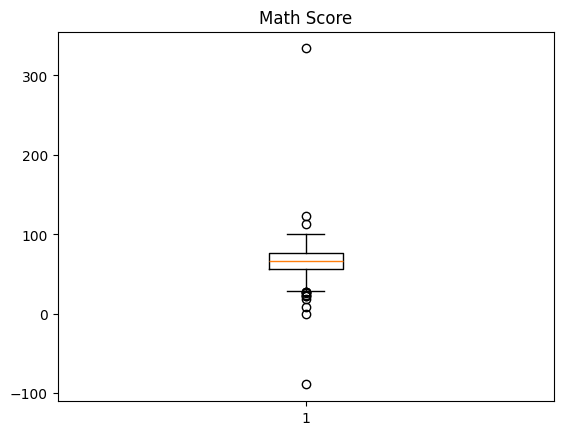

In [31]:
plt.boxplot(df['math score'])
plt.title('Math Score')
plt.show()

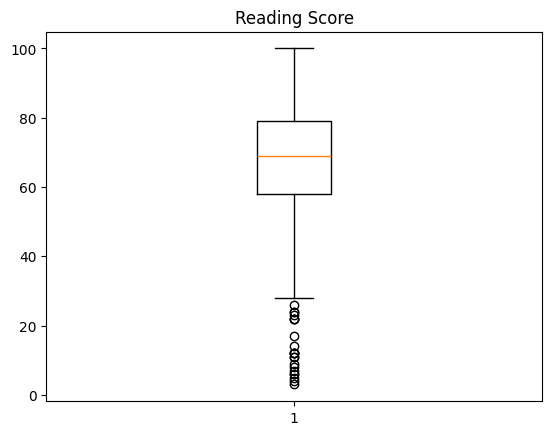

In [33]:
plt.boxplot(df['reading score'])
plt.title('Reading Score')
plt.show()

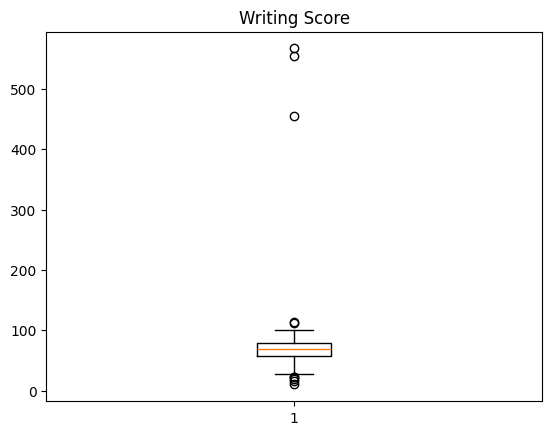

In [34]:
plt.boxplot(df['writing score'])
plt.title('Writing Score')
plt.show()

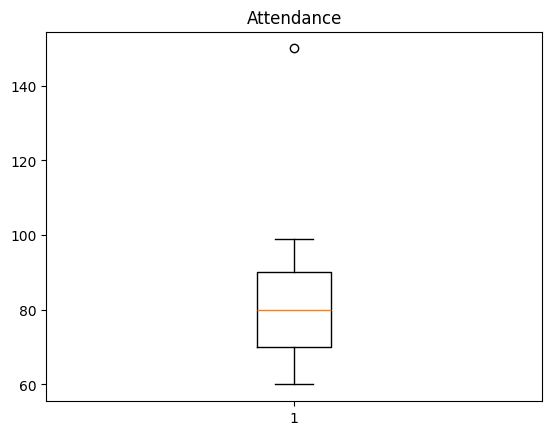

In [35]:
plt.boxplot(df['attendance'])
plt.title('Attendance')
plt.show()

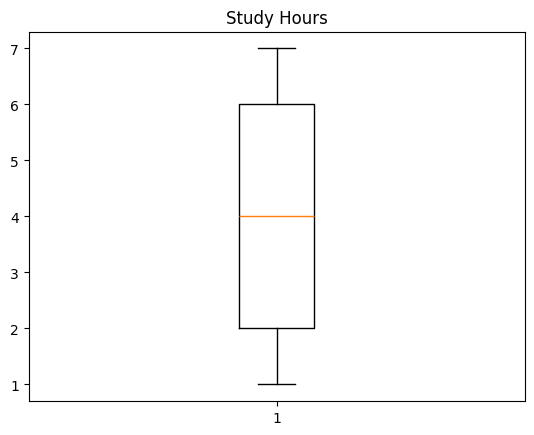

In [47]:
plt.boxplot(df['study_hours'])
plt.title('Study Hours')
plt.show()

##### IQR method:

In [38]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

In [40]:
print("Q1: ", Q1)
print("Q3: ", Q3)
print("IQR: ", IQR)

Q1:  math score       57.0
reading score    58.0
writing score    58.0
attendance       70.0
study_hours       2.0
Name: 0.25, dtype: float64
Q3:  math score       76.0
reading score    79.0
writing score    79.0
attendance       90.0
study_hours       6.0
Name: 0.75, dtype: float64
IQR:  math score       19.0
reading score    21.0
writing score    21.0
attendance       20.0
study_hours       4.0
dtype: float64


In [41]:
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [42]:
print("Lower bound: ", lower_bound)
print("Upper bound: ", upper_bound)

Lower bound:  math score       28.5
reading score    26.5
writing score    26.5
attendance       40.0
study_hours      -4.0
dtype: float64
Upper bound:  math score       104.5
reading score    110.5
writing score    110.5
attendance       120.0
study_hours       12.0
dtype: float64


In [45]:
# counting number of outliers in each column - outlier is defined as values that lie outside of lower and upper bounds
outlier_counts = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).sum()

In [46]:
print(outlier_counts)

math score       14
reading score    23
writing score    10
attendance        1
study_hours       0
dtype: int64


##### Z Score Method:

Z score is a method of calculating deviation from mean. Here an outlier is when the absolute value of Z exceeds 3.

In [50]:
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers_z = (z_scores > 3).sum(axis = 0)

In [52]:
outliers_z

array([ 5, 16,  3,  1,  0])

##### Treating Outliers:

In [53]:
df[numeric_cols] = df[numeric_cols].clip(lower = lower_bound, upper = upper_bound, axis = 1)

In [54]:
new_outlier_counts = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).sum()

In [55]:
print(new_outlier_counts)

math score       0
reading score    0
writing score    0
attendance       0
study_hours      0
dtype: int64


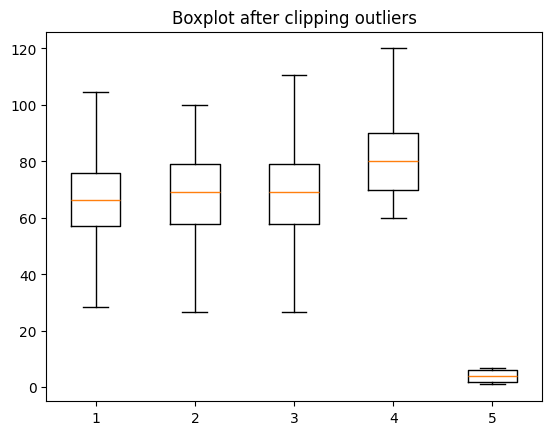

In [56]:
plt.boxplot(df[numeric_cols])
plt.title('Boxplot after clipping outliers')
plt.show()

### Data Scaling and Transformations

We can observe the distribution of data by plotting a histogram for each:

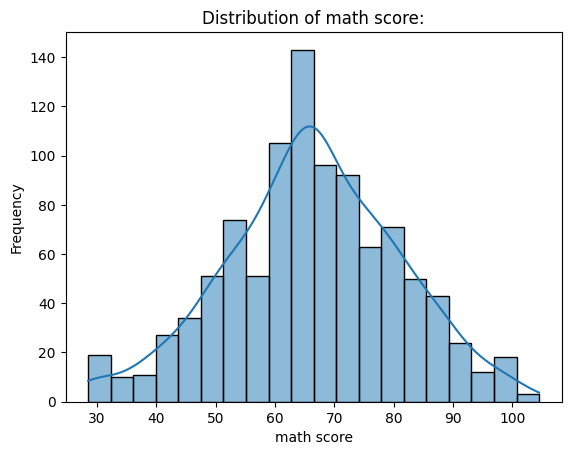

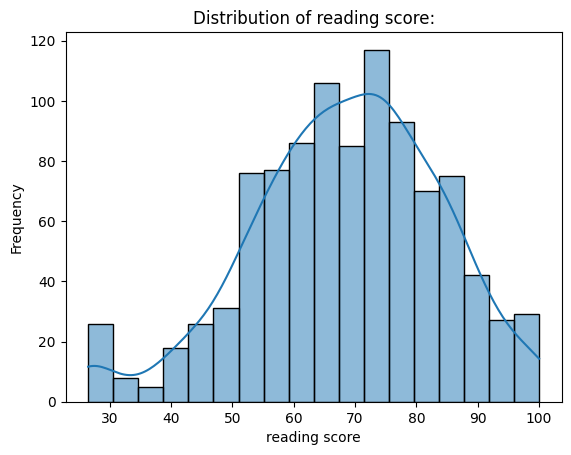

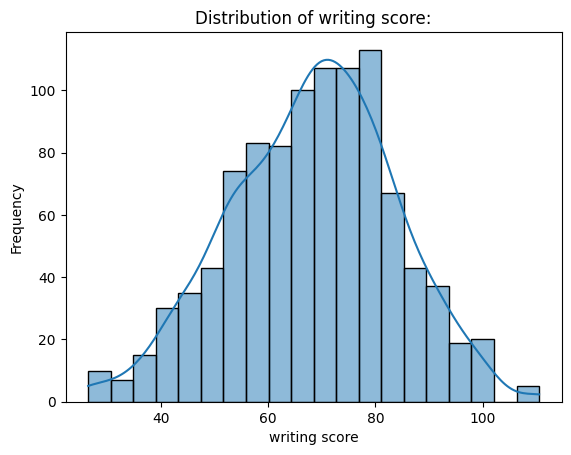

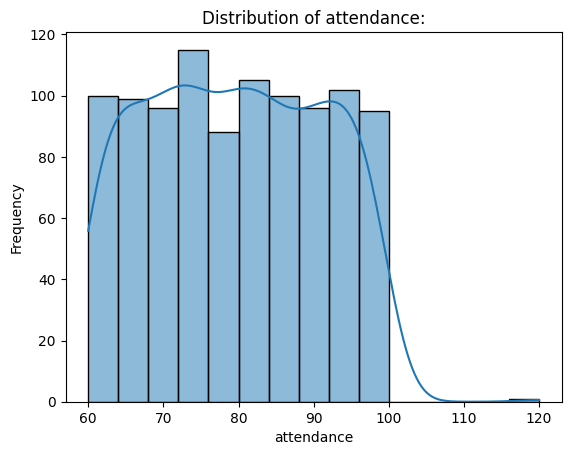

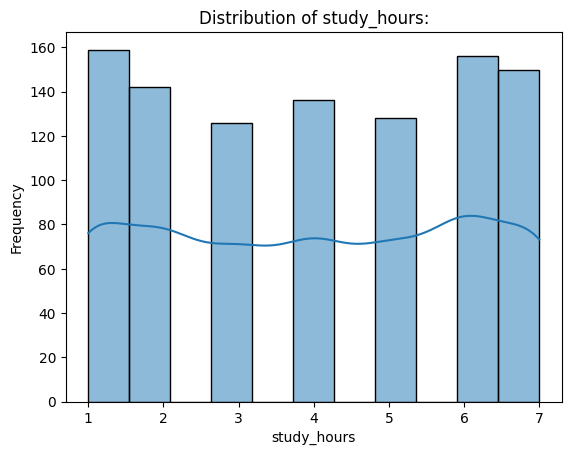

In [59]:
for col in numeric_cols:
    sns.histplot(df[col], kde = True)
    plt.title(f'Distribution of {col}:')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

##### MinMax Scaling:

Min-Max Scaling is a normalization technique that rescales data values to a fixed range, usually between 0 and 1.  
It preserves the relative distribution of data while reducing the effect of differing scales.

In [61]:
minmax_scaler = MinMaxScaler()

In [62]:
df_minmax = df.copy()

In [63]:
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])

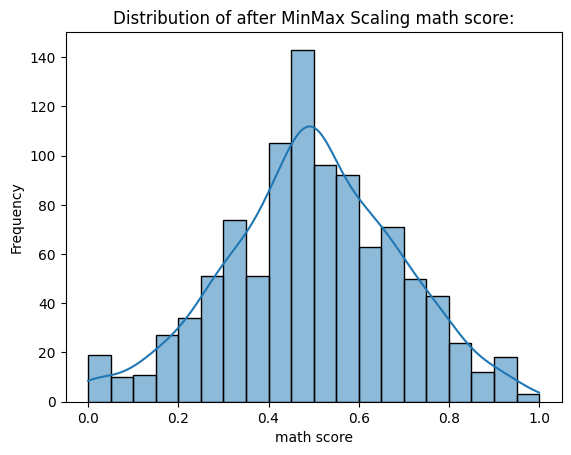

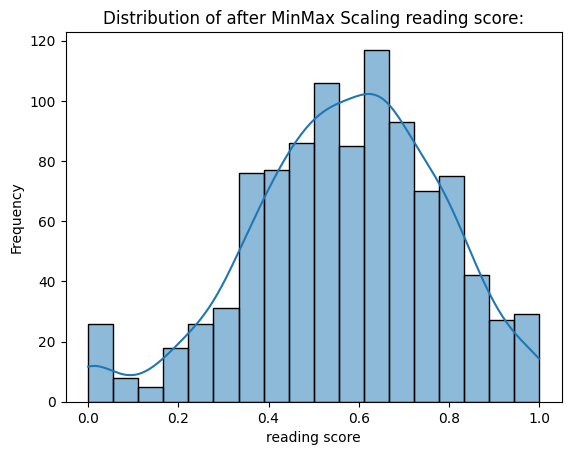

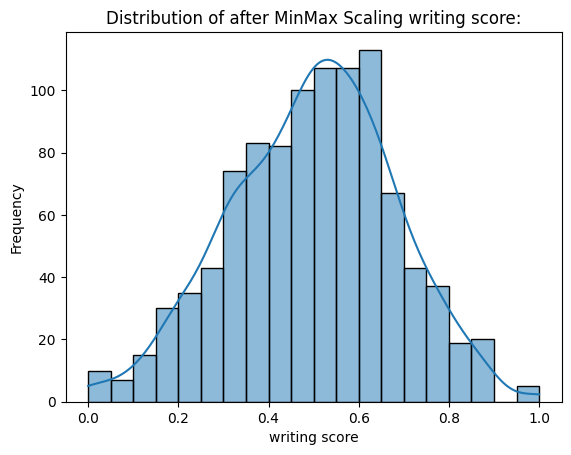

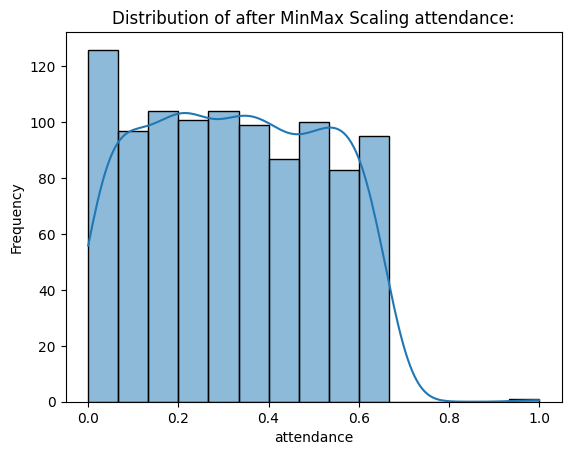

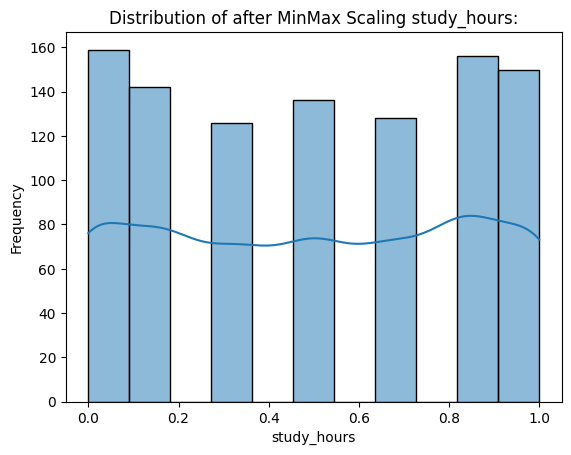

In [64]:
for col in numeric_cols:
    sns.histplot(df_minmax[col], kde = True)
    plt.title(f'Distribution of after MinMax Scaling {col}:')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

##### Standard Scaling:

Standard Scaling is a transformation technique that converts data into a distribution with mean 0 and standard deviation 1.  
It is commonly used when features have different units or scales.

In [65]:
standard_scaler = StandardScaler()

In [66]:
df_stdscale = df.copy()

In [67]:
df_stdscale[numeric_cols] = standard_scaler.fit_transform(df[numeric_cols])

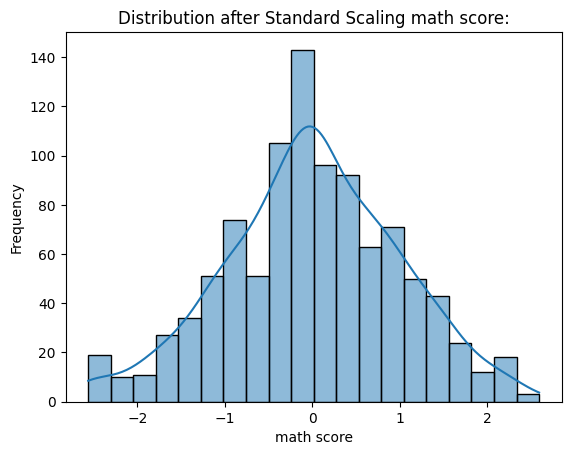

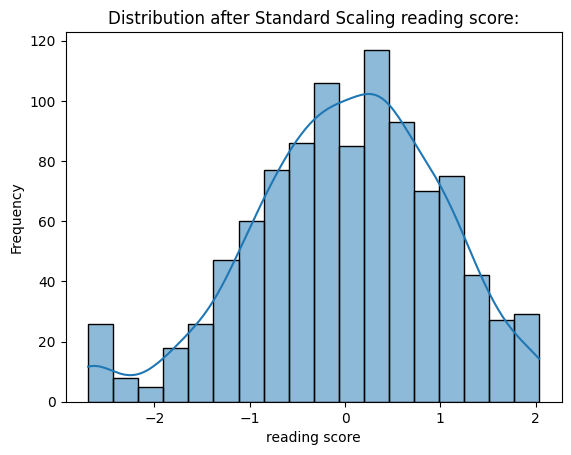

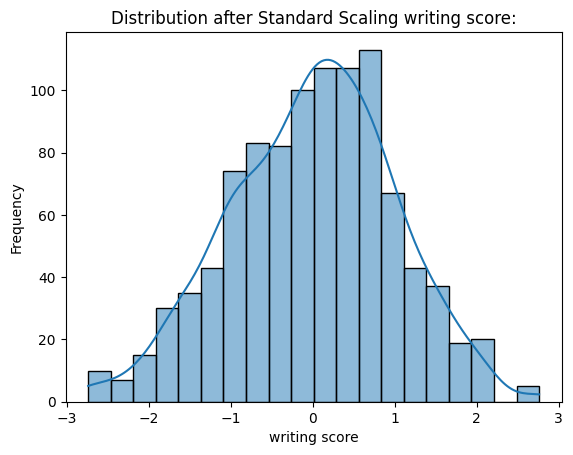

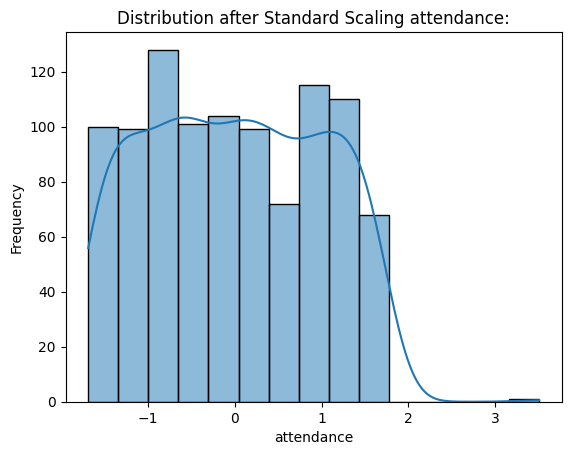

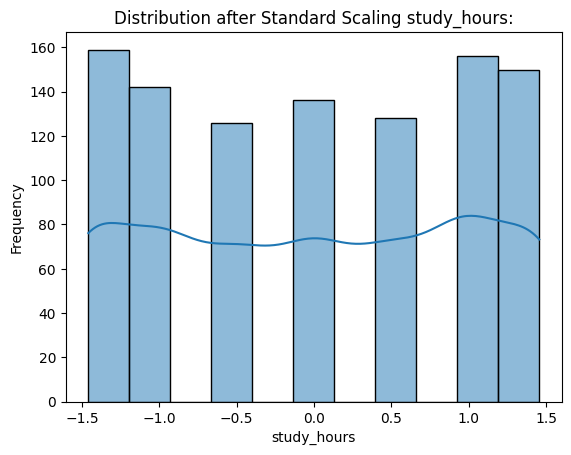

In [68]:
for col in numeric_cols:
    sns.histplot(df_stdscale[col], kde = True)
    plt.title(f'Distribution after Standard Scaling {col}:')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Inferences:
- We used Students Performance as the dataset and performed modifications by adding attendance, number of hours studied and sports to it with introduced inconsistencies.
- We handled any available inconsistencies by imputing with mean values where possible and dropping null values where it was feasible. No duplicates were found.
- We checked for outliers using 2 primary methods: IQR distribution (that displays quartile wise distribution of data, calculated lower and upper bound and found outliers outside that) supported by its boxplot visualization and used the Z Score method (setting threshold at 3) to calculate outliers.
- We handled the outliers by clipping all values outside lower and upper bounds. Supported by boxplot visualization.
- We visualized the distribution of data for each of the numeric value columns using histogram plots with a KDE curve from the seaborn library.
- We applied MinMax Scaler and Standard Scaler data transformation techniques to scale the data between 1 and 0, and then to convert mean to 0 with standard deviation as 1 respectively.